# Yield prediction model comparison: OLS, Ridge, Random Forest, Ridge+PCA

This notebook trains and compares four models to predict **Mean_Yield**:

1. **OLS** (ordinary least squares)
2. **Ridge** (L2-regularized linear regression)
3. **Random Forest** (non-linear ensemble)
4. **Ridge + PCA** (principal components on numeric climate features + ridge)

The goal is to make the comparison **easy to visualize** with:
- a compact metrics table
- bar charts (R², RMSE)
- predicted vs actual plots for each model

> Notes
> - This notebook assumes your data file is named `yields_weather_by_crop.csv` and exists in a `prepared/` folder (or nearby).
> - It automatically detects categorical columns (like `Municipality`, `Crop`) and one-hot encodes them.
> - It applies scaling only where needed (linear models).


In [15]:
# === Imports ===
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from pathlib import Path

from sklearn.base import clone
from sklearn.model_selection import train_test_split, GroupKFold, GridSearchCV, ParameterGrid
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA

from sklearn.metrics import mean_squared_error, r2_score

import matplotlib.pyplot as plt

RANDOM_STATE = 42

SPLIT_METHOD = "group_kfold_year"   # "random", "last_years", "random_years", "group_kfold_year"


In [16]:
# === Load data ===
data_path = "./prepared/yields_weather_by_crop.csv"

df = pd.read_csv(data_path)
print("Shape:", df.shape)
df.head()


Shape: (4864, 78)


,Year,Municipality,Crop,Mean_Yield,05_Q1_CDD,05_Q2_CDD,06_Q1_CDD,06_Q2_CDD,07_Q1_CDD,07_Q2_CDD,...,07_Q1_Ptol,07_Q2_Ptol,08_Q1_Ptol,08_Q2_Ptol,09_Q1_Ptol,09_Q2_Ptol,10_Q1_Ptol,10_Q2_Ptol,Latitude,Longitude
0,1996,ALEXANDER,ARGENTINE CANOLA,0.728428,0.0,1.406025,32.701730,41.166500,31.423716,15.575997,...,0.080075,0.068031,0.044390,0.045396,0.053233,0.024934,0.015926,0.030042,50.6667,-96.5
1,1996,ALEXANDER,OATS,1.215000,0.0,1.406025,32.701730,41.166500,31.423716,15.575997,...,0.080075,0.068031,0.044390,0.045396,0.053233,0.024934,0.015926,0.030042,50.6667,-96.5
2,1996,ALONSA,ALFALFA/GRASS MIX.,1.609253,0.0,2.014729,37.197368,35.920028,39.128350,18.739317,...,0.058935,0.080042,0.030213,0.010850,0.033199,0.015887,0.017048,0.052276,NaN,NaN
3,1996,ARGYLE,ALFALFA,2.080575,0.0,0.152813,24.440870,34.404783,27.131971,17.745561,...,0.030000,0.070000,0.030000,0.030000,0.020000,0.020000,0.000000,0.020000,NaN,NaN
4,1996,ARGYLE,ALFALFA/GRASS MIX.,1.658000,0.0,0.152813,24.440870,34.404783,27.131971,17.745561,...,0.030000,0.070000,0.030000,0.030000,0.020000,0.020000,0.000000,0.020000,NaN,NaN


In [17]:
# === Split features/target ===
TARGET = "Mean_Yield"

y = df[TARGET]

# Use Latitude/Longitude as spatial information instead of Municipality as a categorical feature
drop_cols = [TARGET]
if "Municipality" in df.columns:
    drop_cols.append("Municipality")

X = df.drop(columns=drop_cols)

# Identify categorical vs numeric
cat_cols = [c for c in X.columns if X[c].dtype == "object" or str(X[c].dtype).startswith("category")]
num_cols = [c for c in X.columns if c not in cat_cols]

print(f"Numeric columns: {len(num_cols)}")
print(f"Categorical columns: {len(cat_cols)}")
print("Categorical columns:", cat_cols)


Numeric columns: 75
Categorical columns: 1
Categorical columns: ['Crop']


In [18]:
# === Train / validation / test split ===

def split_dataset(
    X,
    y,
    method="random",
    random_state=42,
    test_size=0.1875,
    val_size=0.1875,
    n_val_years=3,
    n_test_years=3,
    n_train_years=10,
    n_splits=3,
):
    """
    Split dataset using a train/validation/test logic.

    Methods
    -------
    - "random": random row split with proportions 0.625 / 0.1875 / 0.1875
    - "last_years": chronological split by years
    - "random_years": random split by years
    - "group_kfold_year":
        outer split = train+validation years vs final test years
        inner split = GroupKFold(year) on train+validation years for hyperparameter tuning
    """

    if method == "random":
        X_trainval, X_test, y_trainval, y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state
        )
        val_relative_size = val_size / (1.0 - test_size)
        X_train, X_val, y_train, y_val = train_test_split(
            X_trainval, y_trainval, test_size=val_relative_size, random_state=random_state
        )

        print("Random split")
        print("Train size:", X_train.shape, "Validation size:", X_val.shape, "Test size:", X_test.shape)

        return {
            "mode": "holdout",
            "X_train": X_train,
            "X_val": X_val,
            "X_test": X_test,
            "y_train": y_train,
            "y_val": y_val,
            "y_test": y_test,
        }

    elif method == "last_years":
        years = sorted(X["Year"].unique())
        if len(years) < n_val_years + n_test_years + 1:
            raise ValueError("Not enough distinct years for last_years split.")

        test_years = years[-n_test_years:]
        val_years = years[-(n_val_years + n_test_years):-n_test_years]
        train_years = years[:-(n_val_years + n_test_years)]

        print("Train years:", train_years)
        print("Validation years:", val_years)
        print("Test years:", test_years)

        train_mask = X["Year"].isin(train_years)
        val_mask = X["Year"].isin(val_years)
        test_mask = X["Year"].isin(test_years)

        return {
            "mode": "holdout",
            "X_train": X.loc[train_mask],
            "X_val": X.loc[val_mask],
            "X_test": X.loc[test_mask],
            "y_train": y.loc[train_mask],
            "y_val": y.loc[val_mask],
            "y_test": y.loc[test_mask],
            "train_years": train_years,
            "val_years": val_years,
            "test_years": test_years,
        }

    elif method == "random_years":
        rng = np.random.default_rng(random_state)
        years = np.array(sorted(X["Year"].unique()))

        if len(years) < n_train_years + n_val_years + n_test_years:
            raise ValueError("Not enough distinct years for random_years split.")

        chosen_years = rng.choice(years, size=n_train_years + n_val_years + n_test_years, replace=False)
        rng.shuffle(chosen_years)

        train_years = sorted(chosen_years[:n_train_years].tolist())
        val_years = sorted(chosen_years[n_train_years:n_train_years + n_val_years].tolist())
        test_years = sorted(chosen_years[n_train_years + n_val_years:].tolist())

        print("Train years:", train_years)
        print("Validation years:", val_years)
        print("Test years:", test_years)

        train_mask = X["Year"].isin(train_years)
        val_mask = X["Year"].isin(val_years)
        test_mask = X["Year"].isin(test_years)

        return {
            "mode": "holdout",
            "X_train": X.loc[train_mask],
            "X_val": X.loc[val_mask],
            "X_test": X.loc[test_mask],
            "y_train": y.loc[train_mask],
            "y_val": y.loc[val_mask],
            "y_test": y.loc[test_mask],
            "train_years": train_years,
            "val_years": val_years,
            "test_years": test_years,
        }

    elif method == "group_kfold_year":
        years = sorted(X["Year"].unique())
        if len(years) < n_test_years + n_splits:
            raise ValueError("Not enough distinct years for outer test split + GroupKFold.")

        test_years = years[-n_test_years:]
        trainval_years = years[:-n_test_years]

        trainval_mask = X["Year"].isin(trainval_years)
        test_mask = X["Year"].isin(test_years)

        X_trainval = X.loc[trainval_mask].copy()
        y_trainval = y.loc[trainval_mask].copy()
        X_test = X.loc[test_mask].copy()
        y_test = y.loc[test_mask].copy()

        groups = X_trainval["Year"].to_numpy()
        gkf = GroupKFold(n_splits=n_splits)
        cv_splits = list(gkf.split(X_trainval, y_trainval, groups=groups))

        print("Train+validation years:", trainval_years)
        print("Outer test years:", test_years)
        print("Train+validation size:", X_trainval.shape, "Test size:", X_test.shape)
        print("Inner GroupKFold n_splits:", n_splits)

        for fold_id, (_, val_idx) in enumerate(cv_splits, start=1):
            fold_val_years = sorted(X_trainval.iloc[val_idx]["Year"].unique())
            print(f"Fold {fold_id}: validation years = {fold_val_years}")

        return {
            "mode": "cv",
            "X_trainval": X_trainval,
            "X_test": X_test,
            "y_trainval": y_trainval,
            "y_test": y_test,
            "cv_splits": cv_splits,
            "trainval_years": trainval_years,
            "test_years": test_years,
        }

    else:
        raise ValueError(f"Unknown method: {method}")


In [19]:
# === Choose split strategy ===

split_output = split_dataset(
    X,
    y,
    method=SPLIT_METHOD,
    random_state=RANDOM_STATE,
    test_size=0.1875,
    val_size=0.1875,
    n_train_years=10,
    n_val_years=3,
    n_test_years=3,
    n_splits=3,
)


Train+validation years: [np.int64(1996), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008)]
Outer test years: [np.int64(2009), np.int64(2010), np.int64(2011)]
Train+validation size: (3952, 76) Test size: (912, 76)
Inner GroupKFold n_splits: 3
Fold 1: validation years = [np.int64(1996), np.int64(1999), np.int64(2002), np.int64(2005), np.int64(2008)]
Fold 2: validation years = [np.int64(1998), np.int64(2001), np.int64(2004), np.int64(2007)]
Fold 3: validation years = [np.int64(1997), np.int64(2000), np.int64(2003), np.int64(2006)]


## Preprocessing

We use a **ColumnTransformer**:

- **Numeric**: median imputation + (optionally) scaling
- **Categorical**: most-frequent imputation + one-hot encoding

Scaling is applied for linear models (OLS/Ridge/Ridge+PCA). Random Forest does not need scaling.


In [20]:
# === Preprocessing blocks ===

numeric_imputer = SimpleImputer(strategy="median")

categorical_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

preprocess_for_linear = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("impute", numeric_imputer), ("scale", StandardScaler())]), num_cols),
        ("cat", Pipeline([("onehot", categorical_encoder)]), cat_cols),
    ],
    remainder="drop",
)

preprocess_for_rf = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("impute", numeric_imputer)]), num_cols),
        ("cat", Pipeline([("onehot", categorical_encoder)]), cat_cols),
    ],
    remainder="drop",
)


## Models

- **OLS**: baseline, no hyperparameter tuning
- **Ridge**: `alpha` is tuned
- **Random Forest**: tree and regularization hyperparameters are tuned
- **Ridge + PCA**: baseline variant, no hyperparameter tuning in this notebook

For the split logic:

- **random / last_years / random_years**: hyperparameters are chosen on the **validation** set, then the best model is refit on **train + validation** and evaluated on **test**.
- **group_kfold_year**: the last 3 years are the **final test set**, and hyperparameters are chosen with **inner GroupKFold CV by year** on the remaining years.


In [21]:
# === Define model pipelines ===

ols = Pipeline([
    ("prep", preprocess_for_linear),
    ("model", LinearRegression()),
])

ridge = Pipeline([
    ("prep", preprocess_for_linear),
    ("model", Ridge(random_state=RANDOM_STATE)),
])

rf = Pipeline([
    ("prep", preprocess_for_rf),
    ("model", RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

# Ridge + PCA: build a transformer that applies PCA only to numeric block
numeric_pca = Pipeline([
    ("impute", numeric_imputer),
    ("scale", StandardScaler()),
    ("pca", PCA(n_components=0.95, random_state=RANDOM_STATE)),
])

prep_ridge_pca = ColumnTransformer(
    transformers=[
        ("num_pca", numeric_pca, num_cols),
        ("cat", Pipeline([("onehot", categorical_encoder)]), cat_cols),
    ],
    remainder="drop",
)

ridge_pca = Pipeline([
    ("prep", prep_ridge_pca),
    ("model", Ridge(random_state=RANDOM_STATE)),
])

models = {
    "OLS": ols,
    "Ridge": ridge,
    "Random Forest": rf,
    "Ridge + PCA": ridge_pca,
}

param_grids = {
    "Ridge": {
        "model__alpha": np.logspace(-3, 3, 13),
    },
    "Ridge + PCA": {
        "model__alpha": np.logspace(-3, 3, 13),
    },
    "Random Forest": {
        "model__n_estimators": [200, 500],
        "model__max_depth": [None, 10, 20],
        "model__min_samples_leaf": [1, 2, 5],
        "model__max_features": ["sqrt", 0.5, 1.0],
    },
}

list(models.keys())


['OLS', 'Ridge', 'Random Forest', 'Ridge + PCA']

In [22]:
# === Tune, fit and evaluate ===

def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = float(np.sqrt(mse))
    r2 = r2_score(y_true, y_pred)
    return {
        "mse": float(mse),
        "rmse": rmse,
        "r2": float(r2),
    }


def tune_with_validation(model, param_grid, X_train, y_train, X_val, y_val):
    best_model = None
    best_params = None
    best_score = -np.inf
    best_val_pred = None

    for params in ParameterGrid(param_grid):
        candidate = clone(model)
        candidate.set_params(**params)
        candidate.fit(X_train, y_train)
        val_pred = candidate.predict(X_val)
        val_r2 = r2_score(y_val, val_pred)

        if val_r2 > best_score:
            best_score = val_r2
            best_model = candidate
            best_params = params
            best_val_pred = val_pred

    return {
        "best_model": best_model,
        "best_params": best_params,
        "best_val_r2": float(best_score),
        "val_pred": best_val_pred,
    }


def tune_with_group_cv(model, param_grid, X_trainval, y_trainval, cv_splits):
    search = GridSearchCV(
        estimator=clone(model),
        param_grid=param_grid,
        scoring="r2",
        cv=cv_splits,
        n_jobs=-1,
        refit=True,
    )
    search.fit(X_trainval, y_trainval)

    return {
        "best_model": search.best_estimator_,
        "best_params": search.best_params_,
        "best_cv_r2": float(search.best_score_),
        "search": search,
    }


def fit_on_trainval_and_test(model, X_trainval, y_trainval, X_test, y_test):
    fitted = clone(model)
    fitted.fit(X_trainval, y_trainval)
    test_pred = fitted.predict(X_test)
    metrics = regression_metrics(y_test, test_pred)

    return {
        **metrics,
        "pred": test_pred,
        "y_true": np.asarray(y_test),
        "model": fitted,
    }


def evaluate_models(models, param_grids, split_output):
    results = {}

    if split_output["mode"] == "holdout":
        X_train = split_output["X_train"]
        X_val = split_output["X_val"]
        X_test = split_output["X_test"]
        y_train = split_output["y_train"]
        y_val = split_output["y_val"]
        y_test = split_output["y_test"]

        X_trainval = pd.concat([X_train, X_val], axis=0)
        y_trainval = pd.concat([y_train, y_val], axis=0)

        for name, model in models.items():
            if name in param_grids:
                tuning = tune_with_validation(model, param_grids[name], X_train, y_train, X_val, y_val)
                final_eval = fit_on_trainval_and_test(
                    model=tuning["best_model"],
                    X_trainval=X_trainval,
                    y_trainval=y_trainval,
                    X_test=X_test,
                    y_test=y_test,
                )
                results[name] = {
                    **final_eval,
                    "tuning_mode": "validation",
                    "best_params": tuning["best_params"],
                    "selection_score": tuning["best_val_r2"],
                    "selection_metric": "Validation R2",
                }
            else:
                final_eval = fit_on_trainval_and_test(
                    model=model,
                    X_trainval=X_trainval,
                    y_trainval=y_trainval,
                    X_test=X_test,
                    y_test=y_test,
                )
                results[name] = {
                    **final_eval,
                    "tuning_mode": "none",
                    "best_params": None,
                    "selection_score": np.nan,
                    "selection_metric": None,
                }

    elif split_output["mode"] == "cv":
        X_trainval = split_output["X_trainval"]
        X_test = split_output["X_test"]
        y_trainval = split_output["y_trainval"]
        y_test = split_output["y_test"]
        cv_splits = split_output["cv_splits"]

        for name, model in models.items():
            if name in param_grids:
                tuning = tune_with_group_cv(model, param_grids[name], X_trainval, y_trainval, cv_splits)
                final_eval = fit_on_trainval_and_test(
                    model=tuning["best_model"],
                    X_trainval=X_trainval,
                    y_trainval=y_trainval,
                    X_test=X_test,
                    y_test=y_test,
                )
                results[name] = {
                    **final_eval,
                    "tuning_mode": "group_cv",
                    "best_params": tuning["best_params"],
                    "selection_score": tuning["best_cv_r2"],
                    "selection_metric": "Inner CV R2",
                }
            else:
                final_eval = fit_on_trainval_and_test(
                    model=model,
                    X_trainval=X_trainval,
                    y_trainval=y_trainval,
                    X_test=X_test,
                    y_test=y_test,
                )
                results[name] = {
                    **final_eval,
                    "tuning_mode": "none",
                    "best_params": None,
                    "selection_score": np.nan,
                    "selection_metric": None,
                }
    else:
        raise ValueError("Unknown split mode")

    metrics = (
        pd.DataFrame({
            name: {
                "Selection score": res["selection_score"],
                "R2": res["r2"],
                "RMSE": res["rmse"],
                "MSE": res["mse"],
                "Best params": str(res["best_params"]),
                "Tuning mode": res["tuning_mode"],
            }
            for name, res in results.items()
        })
        .T
        .sort_values("R2", ascending=False)
    )

    return results, metrics


In [23]:
results, metrics = evaluate_models(models, param_grids, split_output)
metrics


,Selection score,R2,RMSE,MSE,Best params,Tuning mode
Ridge + PCA,0.865191,0.883526,0.538897,0.29041,{'model__alpha': np.float64(0.03162277660168379)},group_cv
Random Forest,0.872995,0.867009,0.575842,0.331594,"{'model__max_depth': 20, 'model__max_features'...",group_cv
Ridge,0.707252,0.637888,0.950195,0.902871,{'model__alpha': np.float64(3.1622776601683795)},group_cv
OLS,NaN,0.603948,0.993729,0.987497,None,none


## Easy-to-visualize comparison

1) **Metrics table** sorted by **test R²**

2) **Selection score** indicates how the model was chosen:
- validation R² for `random`, `last_years`, `random_years`
- inner GroupKFold CV R² for `group_kfold_year`

3) All plots below are based on the **final test set only**


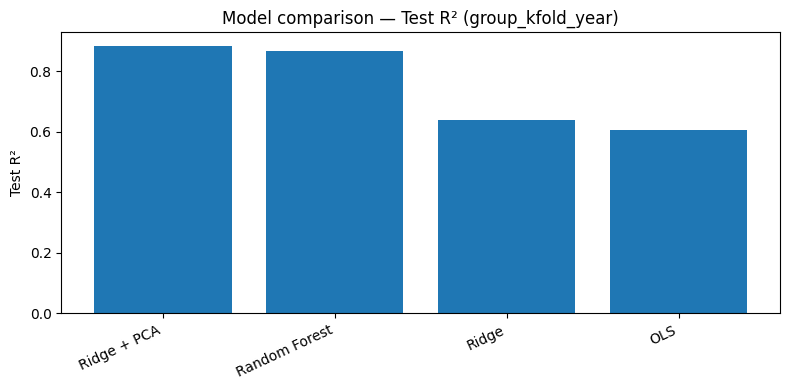

In [24]:
# === Bar chart: test R² ===
plt.figure(figsize=(8, 4))
plt.bar(metrics.index, metrics["R2"].astype(float))
plt.ylabel("Test R²")
plt.title(f"Model comparison — Test R² ({SPLIT_METHOD})")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


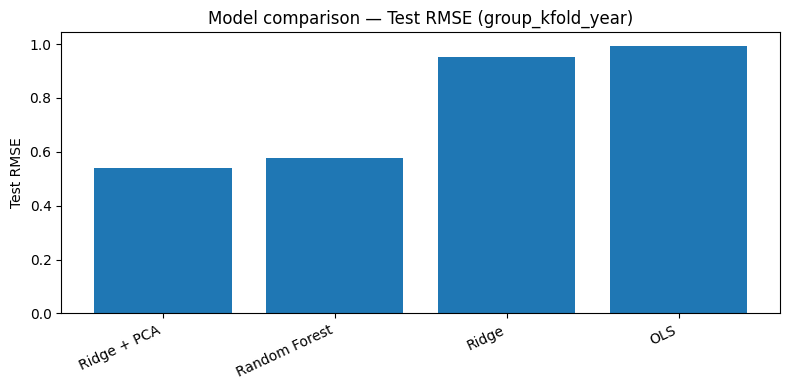

In [25]:
# === Bar chart: test RMSE ===
plt.figure(figsize=(8, 4))
plt.bar(metrics.index, metrics["RMSE"].astype(float))
plt.ylabel("Test RMSE")
plt.title(f"Model comparison — Test RMSE ({SPLIT_METHOD})")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


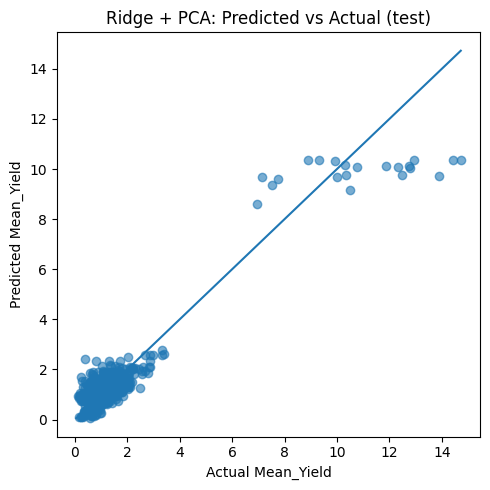

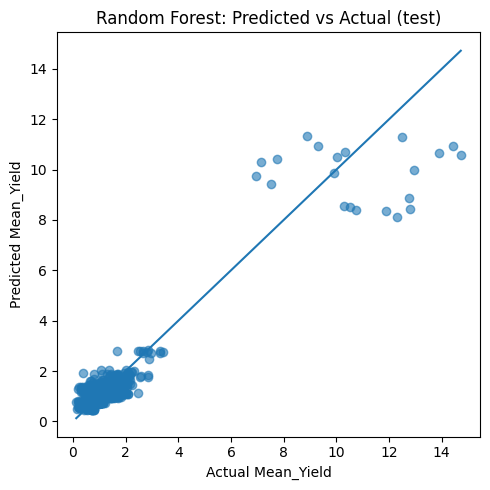

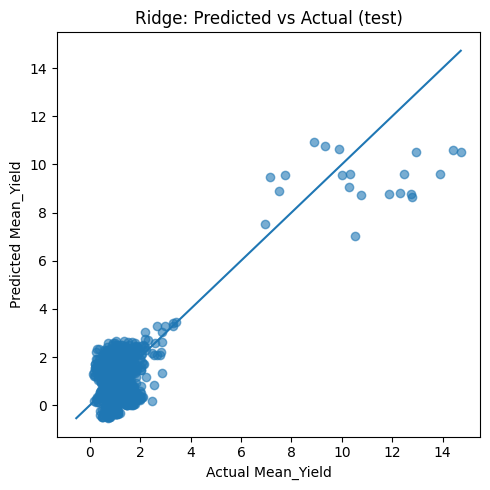

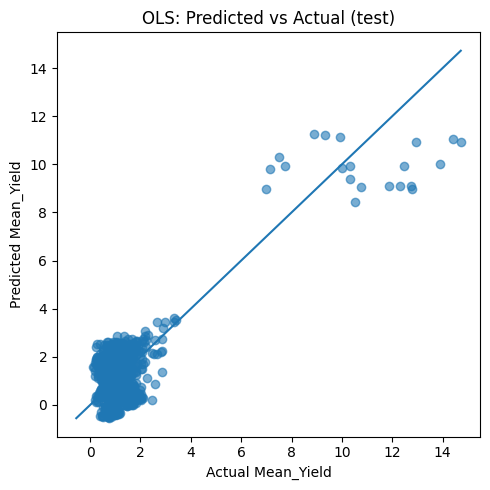

In [26]:
# === Predicted vs Actual on test set ===

for name in metrics.index:
    y_true = results[name]["y_true"]
    y_pred = results[name]["pred"]

    plt.figure(figsize=(5, 5))
    plt.scatter(y_true, y_pred, alpha=0.6)

    lo = float(min(y_true.min(), y_pred.min()))
    hi = float(max(y_true.max(), y_pred.max()))
    plt.plot([lo, hi], [lo, hi])

    plt.xlabel("Actual Mean_Yield")
    plt.ylabel("Predicted Mean_Yield")
    plt.title(f"{name}: Predicted vs Actual (test)")
    plt.tight_layout()
    plt.show()


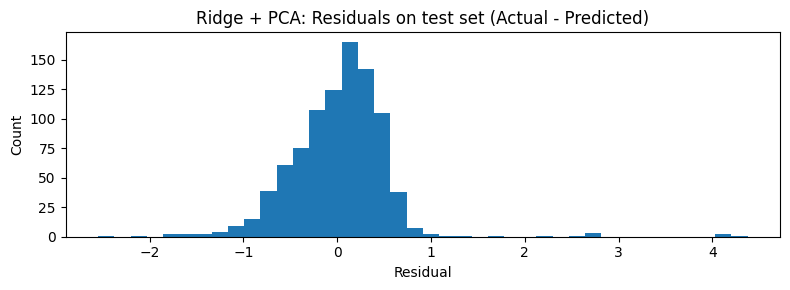

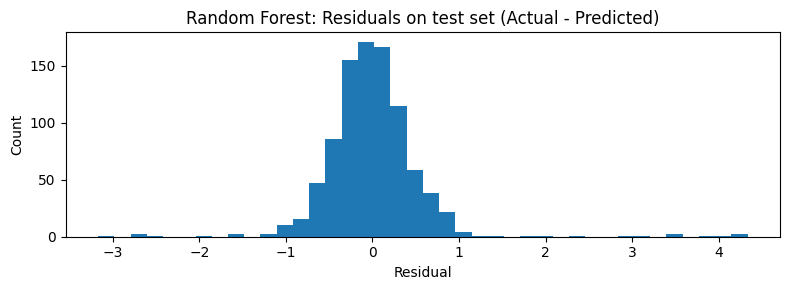

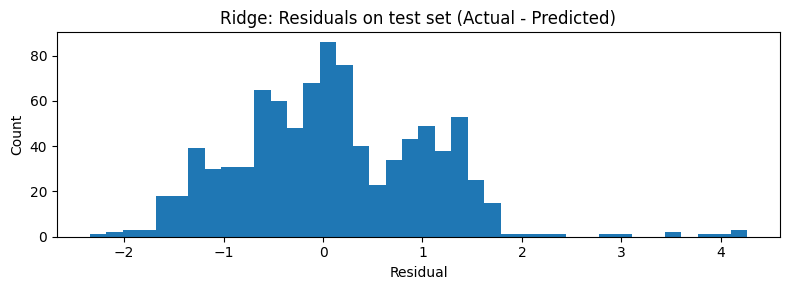

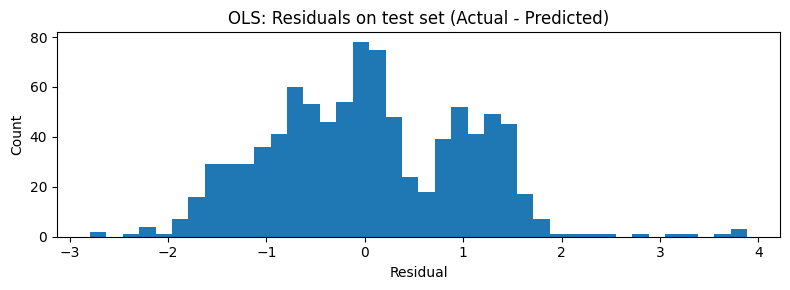

In [27]:
# === Residual distribution per model on test set ===

for name in metrics.index:
    y_true = results[name]["y_true"]
    y_pred = results[name]["pred"]
    residuals = y_true - y_pred

    plt.figure(figsize=(8, 3))
    plt.hist(residuals, bins=40)
    plt.title(f"{name}: Residuals on test set (Actual - Predicted)")
    plt.xlabel("Residual")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


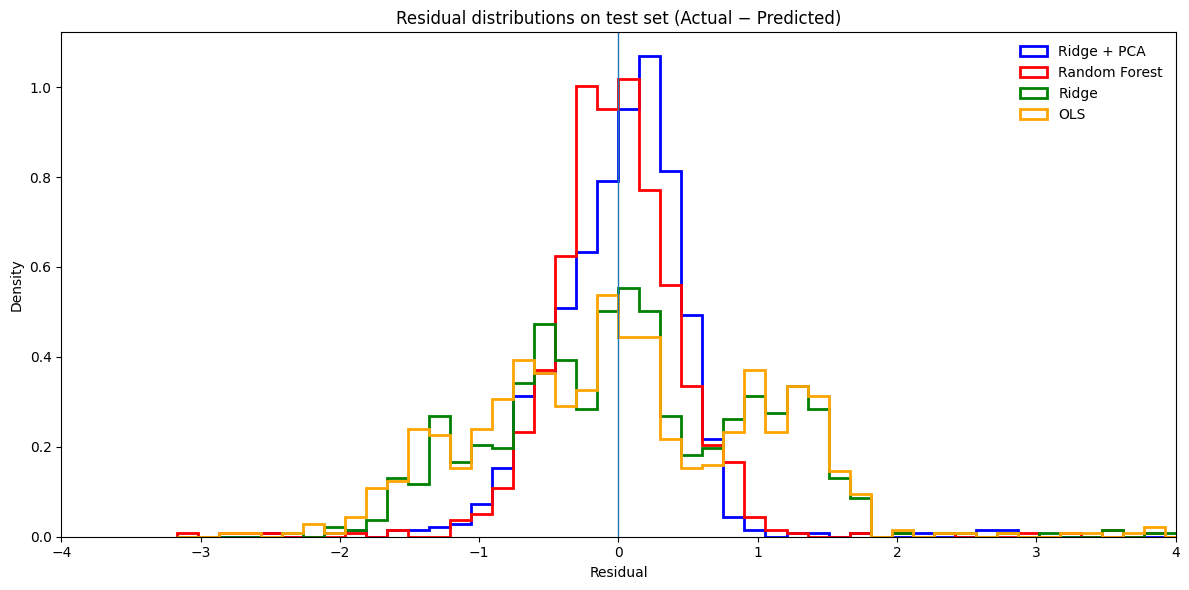

In [28]:
# === Combined residual distributions on test set ===

residuals_by_model = {}

for name in metrics.index:
    y_true = results[name]["y_true"]
    y_pred = results[name]["pred"]
    residuals_by_model[name] = y_true - y_pred

all_res = np.concatenate(list(residuals_by_model.values()))
bins = np.histogram_bin_edges(all_res, bins=50)

colors = ["blue", "red", "green", "orange"]

plt.figure(figsize=(12, 6))

for (name, res), color in zip(residuals_by_model.items(), colors):
    plt.hist(
        res,
        bins=bins,
        histtype="step",
        linewidth=2,
        density=True,
        label=name,
        color=color,
    )

plt.axvline(0, linewidth=1)
plt.xlim(-4, 4)
plt.title("Residual distributions on test set (Actual − Predicted)")
plt.xlabel("Residual")
plt.ylabel("Density")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()
